# 5a — Main Network Hazard Criticality

## Purpose
Combine the single-point-of-failure criticality results of the main road network with five hazard overlays — floods (with DEM-based depth bias correction), snow drift, landslides, wildfires, and pavement heat — into one main-network hazard exposure dataset. All vector outputs are saved to parquet + ArcGIS File Geodatabase + Excel in EPSG:6316.

## Inputs
| File | Description |
|------|-------------|
| `intermediate_results/criticality_results.parquet` | Single-point-of-failure criticality results (step 2) |
| `input_files/Deonice_Februar_2025.shp` | Baseline road sections (segments missing from criticality results are appended) |
| `input_files/ne_10m_admin_0_countries.shp` | Natural Earth country boundaries (Serbia / Kosovo) |
| `input_files/Europe_RP100_filled_depth.tif` | European fluvial flood depth raster (100-year RP) |
| `input_files/Vertical coordinates/RSDP_Feb_2026/RSDP_Feb_2026/Deonice/RSDP_Deonice_Feb_2026.shp` | Road sections with measured Z coordinates |
| `input_files/dem_serbia.tif` | Digital elevation model of Serbia |
| `input_files/snezni_nanosi_studije.shp` | Snow-drift segment locations |
| `input_files/Nestabilne_pojave.shp` | Landslide occurrences (filtered to *Klizište*) |
| `input_files/wildfire risk/stepen ugrozenosti od pozara Srbijasume.tif` | Wildfire susceptibility raster |
| `intermediate_results/future_pavement_temperatures.tif` | Future UHI-adjusted pavement temperature raster (step 4c) |

## Outputs
| File | Description |
|------|-------------|
| `figures/elevation_profiles_by_category.png` | Example measured-Z vs DEM elevation profiles per road category |
| `figures/elevation_bias_by_category.png` | Median/mean elevation bias with 95% CIs per category |
| `figures/flood_exposure_correction.png` | Flood exposure before (A) and after (B) bias correction |
| `figures/vehicle_hours_lost_map_flooded.png` | VHL map for flood-exposed roads |
| `figures/vhl_hazards_comparison.png` | 2×2 VHL comparison (floods, snow, landslides, wildfires) |
| `figures/phl_hazards_comparison.png` | 2×2 PHL comparison |
| `figures/tkl_hazards_comparison.png` | 2×2 TKL comparison |
| `intermediate_results/parquet/hazard_exposure/main_network_hazard_exposure.parquet` | Combined hazard exposure (EPSG:6316) |
| `intermediate_results/parquet/hazard_exposure/main_network_hazard_exposure.xlsx` | Excel attribute table (no geometry) |
| `intermediate_results/database/hazard_exposure/hazard_exposure.gdb` | GDB layer `main_network_hazard_exposure` |

## Key Processing Steps
1. **Merge baseline roads** — append Deonice sections missing from the criticality results (core Serbia only, Kosovo excluded); zero-fill metric columns
2. **Flood exposure** — DamageScanner exposure against the RP100 flood raster; flag segments with depth > 0.25 m
3. **Elevation bias analysis** — compare measured road Z-profiles against the DEM; bootstrap 95% CIs of the bias per road category
4. **Bias correction** — subtract per-category bias (IA: 4.60 m, IM: 3.66 m, IB/IIA/IIB: 0.82 m) from max flood depth, clipped at 0
5. **Hazard overlays** — spatial joins for snow drift and landslides (Klizište, 10 m buffer); binary wildfire exposure via DamageScanner; max pavement temperature via zonal statistics
6. **Combine and save** — aggregate per-segment hazard attributes; keep segments exposed to ≥ 1 hazard with valid VHL; save to parquet + GDB + Excel (EPSG:6316)
7. **Comparison figures** — 2×2 VHL/PHL/TKL maps per hazard
8. **Summary statistics** — disruption metrics, multi-hazard overlap, national-scale comparison

In [1]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd

BASE_DIR = Path(r"C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia")
sys.path.append(str(BASE_DIR))

from utils.criticality_functions import (
    FINAL_ELEVATION_BIAS,
    apply_bias_correction,
    build_hazard_count,
    calculate_flood_exposure,
    calculate_heat_exposure,
    calculate_vhl_landslides,
    calculate_vhl_snowdrift,
    calculate_wildfire_exposure,
    combine_hazard_exposure,
    compute_bias_confidence_intervals,
    compute_bias_statistics,
    extract_profiles,
    fill_missing_categories,
    flag_future_precipitation,
    load_vertical_coordinates,
    merge_baseline_roads,
    plot_all_hazard_comparisons,
    plot_elevation_bias,
    plot_elevation_profiles,
    plot_flood_exposure_correction,
    plot_hazard_count_map,
    plot_vhl_flooded_map,
    print_hazard_analysis_summary,
    save_criticality_vector,
    summarize_hazard_counts,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [2]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
parquet_dir = intermediate_results_path / "parquet" / "hazard_exposure"
gdb_path = intermediate_results_path / "database" / "hazard_exposure" / "hazard_exposure.gdb"
output_crs = "EPSG:6316"

VERTICAL_COORDINATES_SHP = (
    data_path / "Vertical coordinates" / "RSDP_Feb_2026" / "RSDP_Feb_2026"
    / "Deonice" / "RSDP_Deonice_Feb_2026.shp"
)

In [ ]:
# Load criticality results and merge with the baseline road sections
gdf_results = gpd.read_parquet(intermediate_results_path / "parquet" / "travel_disruptions" / "criticality_results.parquet")
gdf_results = merge_baseline_roads(
    gdf_results,
    baseline_roads_path=data_path / "Deonice_Februar_2025.shp",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)

In [4]:
# Flood exposure via DamageScanner (exposed = any depth > 0.25 m)
exposed_roads, country_plot = calculate_flood_exposure(
    gdf_results,
    flood_path=data_path / "Europe_RP100_filled_depth.tif",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)
exposed_roads = fill_missing_categories(exposed_roads)

convert coverage to meters: 100%|██████████| 1329/1329 [00:00<00:00, 105578.54it/s]


## Elevation Bias Analysis (Road Z-Profiles vs DEM)

In [5]:
# Load road sections with measured Z coordinates and extract elevation profiles
vertical_coordinates, vertical_coordinates_4326 = load_vertical_coordinates(VERTICAL_COORDINATES_SHP)
vertical_coordinates = extract_profiles(
    vertical_coordinates, vertical_coordinates_4326, dem_path=data_path / "dem_serbia.tif"
)

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Roads with complete Z profiles: 153


Extracting profiles: 100%|██████████| 153/153 [00:03<00:00, 50.54it/s]


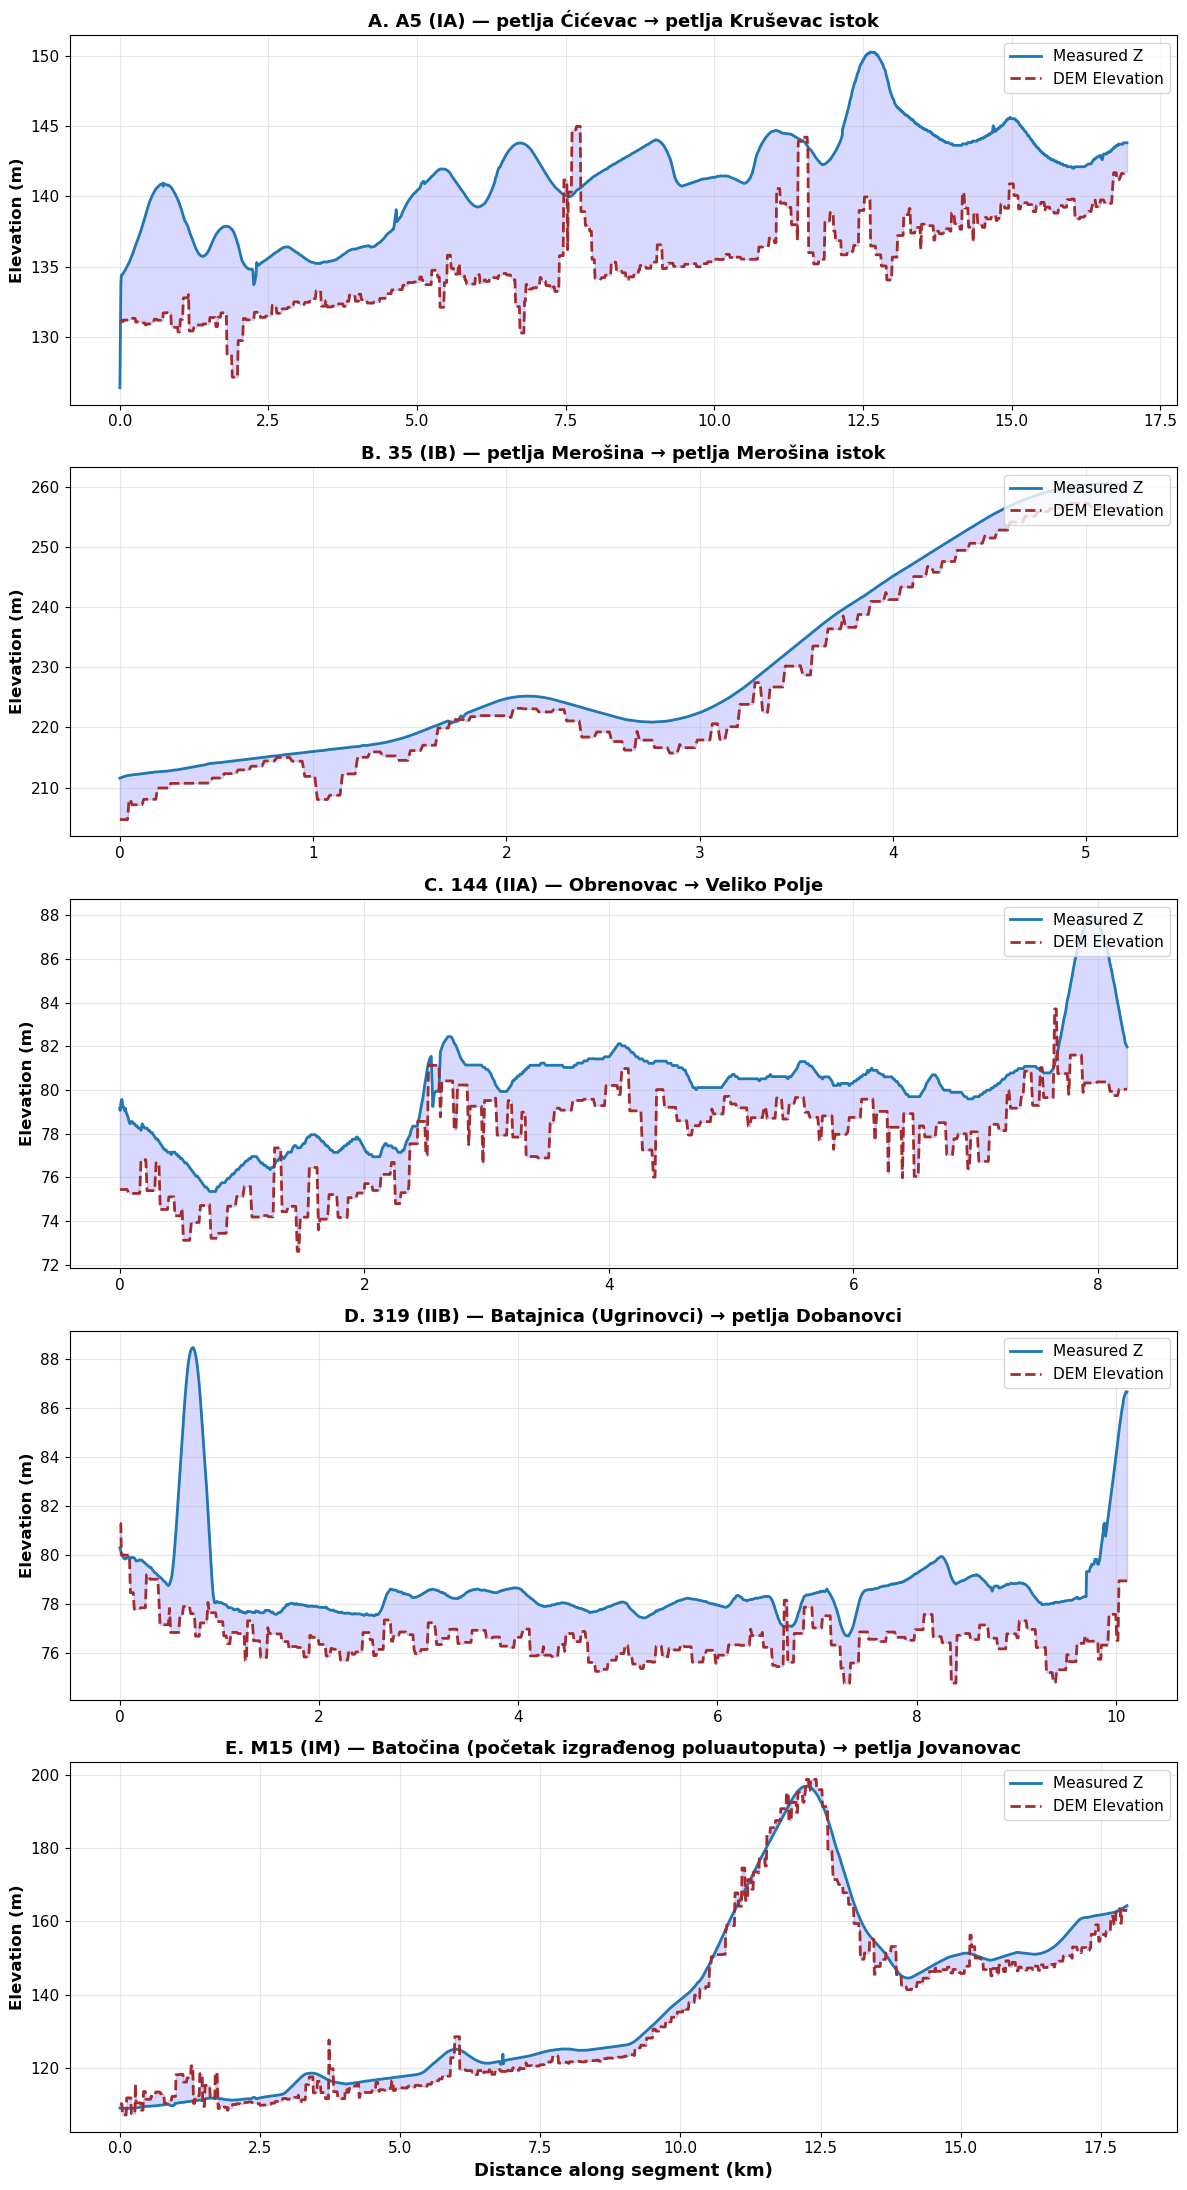

In [6]:
plot_elevation_profiles(vertical_coordinates, figure_path)

In [7]:
# Per-road bias statistics (measured Z minus DEM) and bootstrap 95% CIs per category
clean = compute_bias_statistics(vertical_coordinates)
ci_df = compute_bias_confidence_intervals(clean)

Roads with Z data: 151
Median bias per category: {'IA': 4.601053571428055, 'IB': 2.5885321098498104, 'IIA': 0.6095876782079163, 'IIB': 1.1351122123893485, 'IM': 3.659322115384341}
PutKateg  n   median  median_ci_low  median_ci_high      mean  mean_ci_low  mean_ci_high
      IA 35 4.601054       3.998717        5.591072  4.768886     4.207295      5.330478
      IB 22 2.588532       0.039983        3.422338  1.999851     0.807977      3.191724
     IIA 35 0.609588      -0.863578        0.896040 -0.430597    -1.700040      0.838847
     IIB 13 1.135112      -0.664770        3.531355  0.471914    -3.496995      4.440824
      IM 42 3.659322       3.253271        4.375735  3.615684     2.889432      4.341937

Pooled IIA+IIB (n=48)
Median: 0.64 m
95% CI: [-0.31, 1.07]


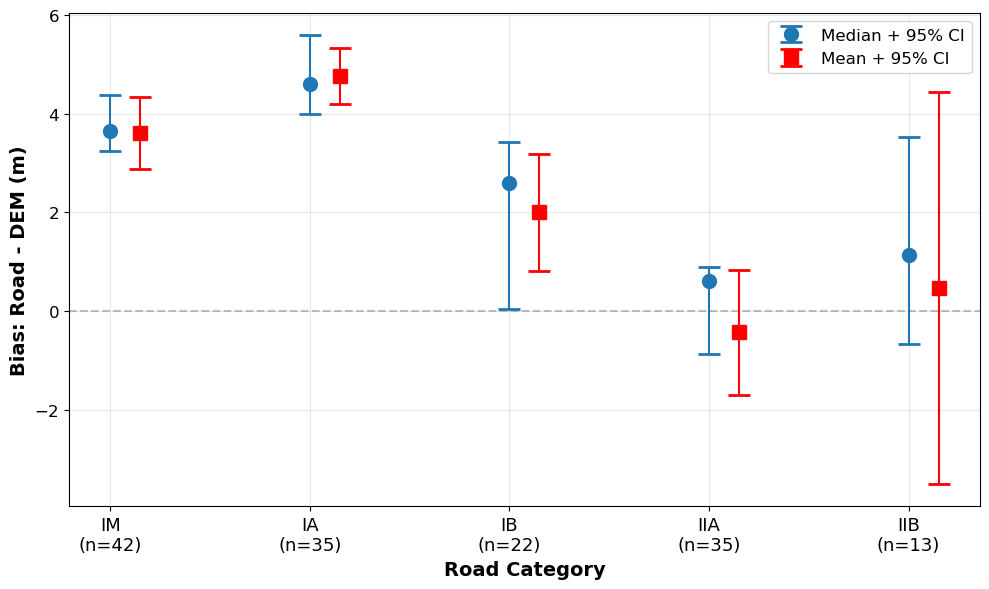

In [8]:
plot_elevation_bias(ci_df, figure_path)

In [9]:
# Apply the derived per-category elevation bias to the flood depths
print(f"Applied bias (m): {FINAL_ELEVATION_BIAS}")
exposed_roads = apply_bias_correction(exposed_roads)

Applied bias (m): {'IA': 4.601, 'IM': 3.659, 'IB': 0.82, 'IIA': 0.82, 'IIB': 0.82}
kategorija  total  originally_flooded  still_flooded  bias  avg_original_depth  avg_corrected_depth  removed  pct_removed
        IA    419                 419             84 4.601            2.813000             0.450076      335         80.0
        IB    331                 331            314 0.820            5.104647             4.298202       17          5.1
       IIA    408                 408            352 0.820            4.018478             3.246664       56         13.7
       IIB    109                 109             91 0.820            3.525615             2.756064       18         16.5
        IM     55                  55             18 3.659            3.295364             0.990527       37         67.3


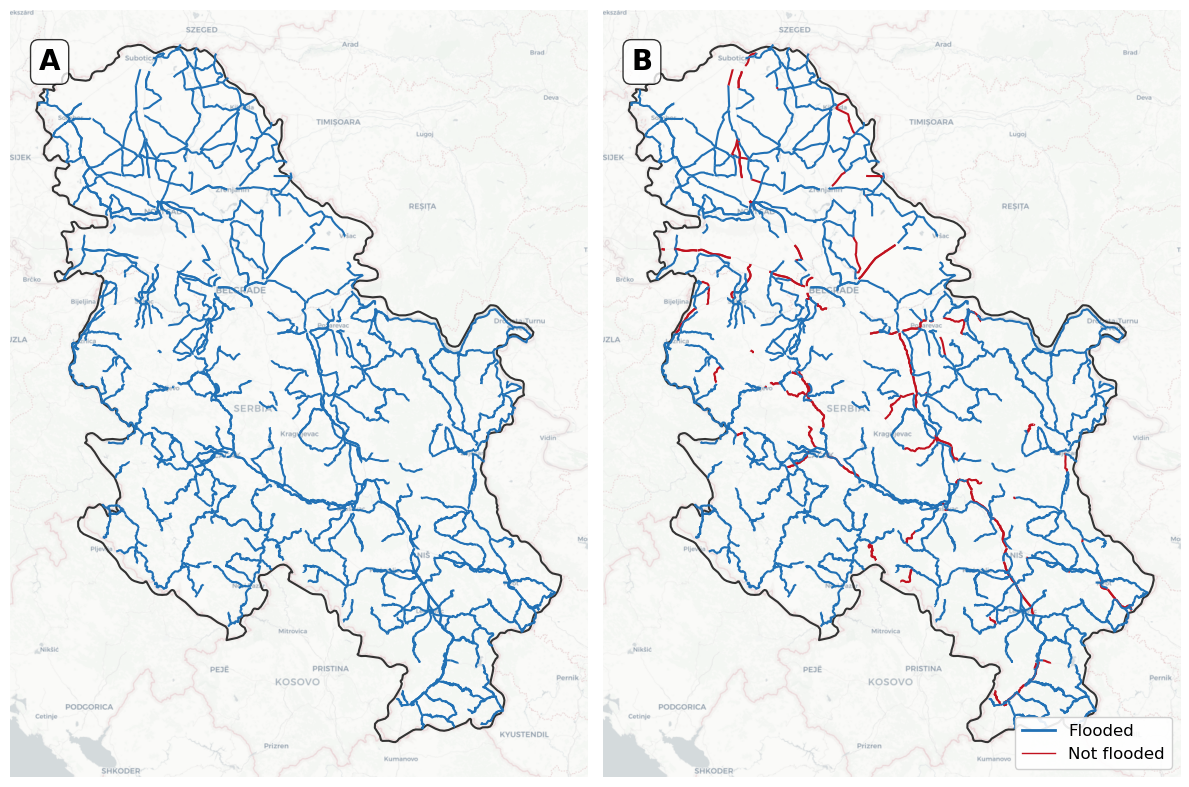

In [10]:
plot_flood_exposure_correction(exposed_roads, country_plot, figure_path)

## Flood-Exposed Roads With Criticality

In [11]:
corrected_roads = exposed_roads.loc[exposed_roads.corrected_max_depth > 0]
gdf_vhl_flooded = gdf_results.merge(
    corrected_roads.loc[corrected_roads.exposed][["coverage", "values", "corrected_max_depth"]],
    left_index=True,
    right_index=True,
)

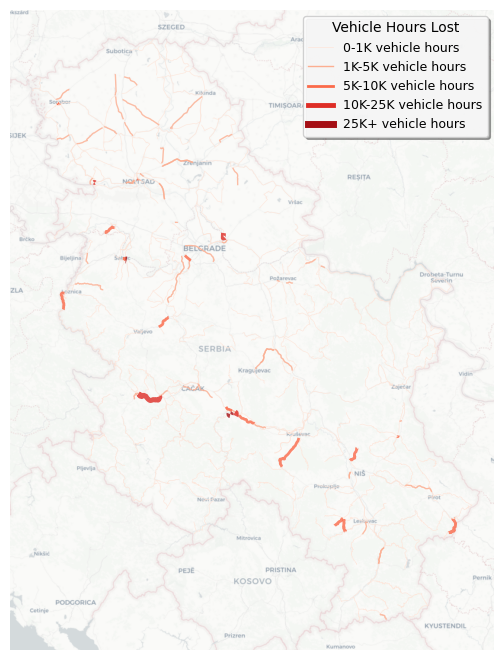

In [12]:
plot_vhl_flooded_map(gdf_vhl_flooded, figure_path)

## Other Hazard Overlays

In [13]:
# Snow drift: spatial join of road segments with snow-drift locations
gdf_vhl_snowdrift = calculate_vhl_snowdrift(gdf_results, data_path / "snezni_nanosi_studije.shp")

c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'
  return ogr_read(


In [14]:
# Landslides: tip=='Klizište' only, 10 m buffer
gdf_vhl_landslides = calculate_vhl_landslides(gdf_results, data_path / "Nestabilne_pojave.shp")

In [15]:
# Wildfire: binary exposure (any susceptibility class > 0) via DamageScanner
gdf_vhl_wildfire = calculate_wildfire_exposure(
    gdf_results,
    wildfire_path=data_path / "wildfire risk" / "stepen ugrozenosti od pozara Srbijasume.tif",
    world_path=data_path / "ne_10m_admin_0_countries.shp",
)

Overlay raster with vector: 100%|██████████| 49/49 [00:21<00:00,  2.24it/s]


In [16]:
# Heat: max future pavement temperature (UHI raster) per road segment
gdf_vhl_heat = calculate_heat_exposure(
    gdf_results, intermediate_results_path / "future_pavement_temperatures.tif"
)

## Combine Hazards and Save

In [17]:
gdf_hazards = combine_hazard_exposure(
    gdf_results, gdf_vhl_flooded, gdf_vhl_snowdrift,
    gdf_vhl_landslides, gdf_vhl_wildfire, gdf_vhl_heat,
)

save_criticality_vector(
    gdf_hazards,
    parquet_dir=parquet_dir,
    gdb_path=gdb_path,
    layer_name="main_network_hazard_exposure",
    output_crs=output_crs,
)

Saved main_network_hazard_exposure -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\main_network_hazard_exposure.parquet
Saved main_network_hazard_exposure -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\database\hazard_exposure\hazard_exposure.gdb (layer 'main_network_hazard_exposure')
Saved main_network_hazard_exposure -> C:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\parquet\hazard_exposure\main_network_hazard_exposure.xlsx


### Map of main network impacts

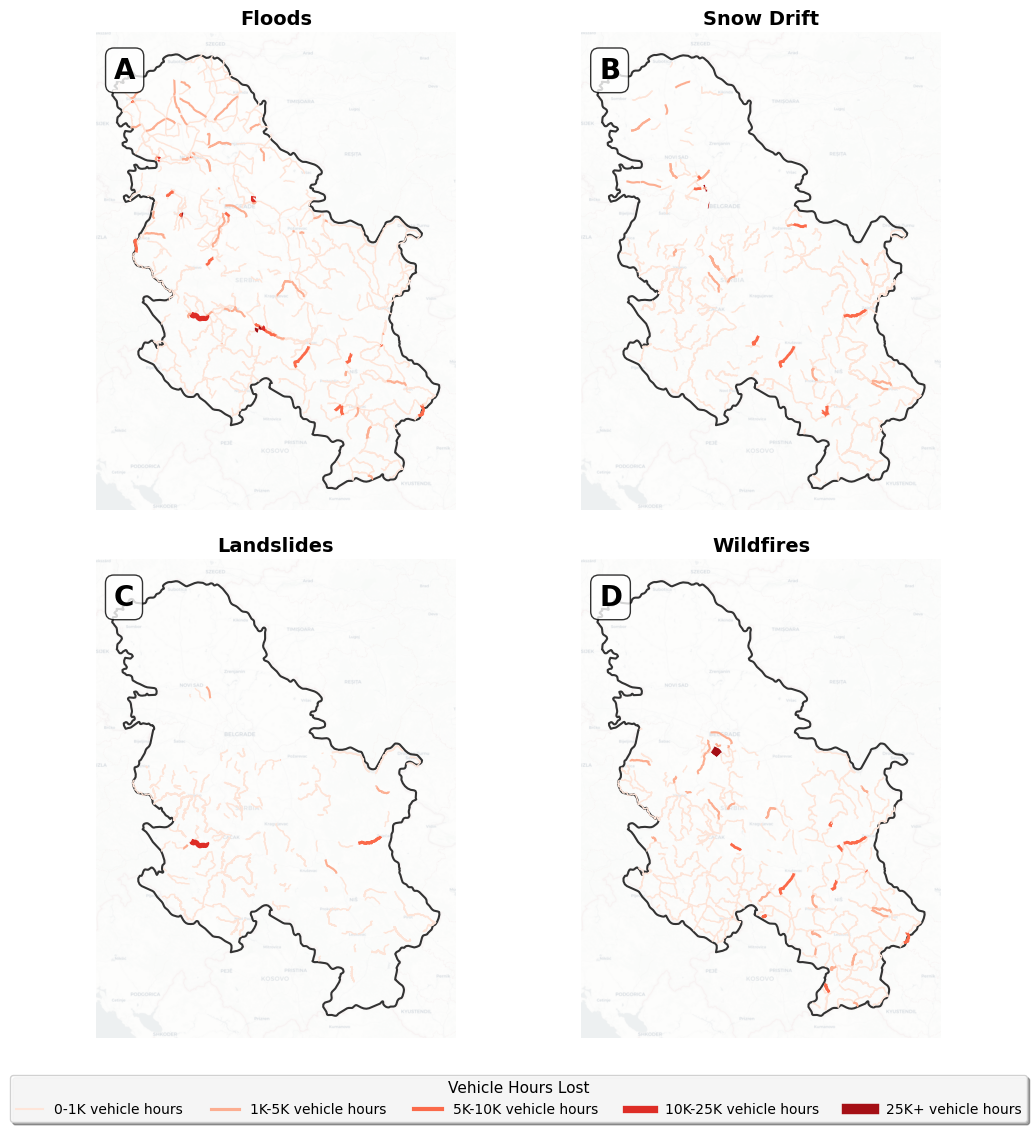

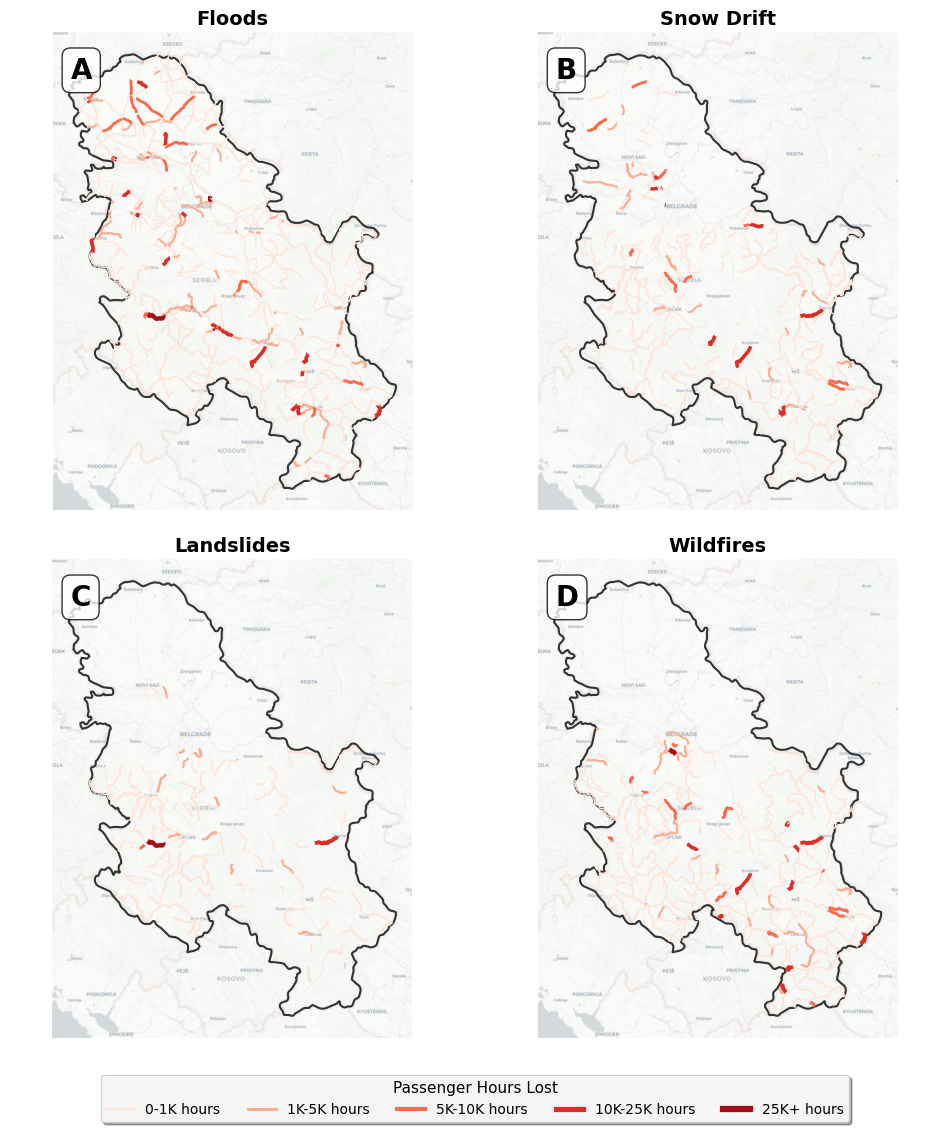

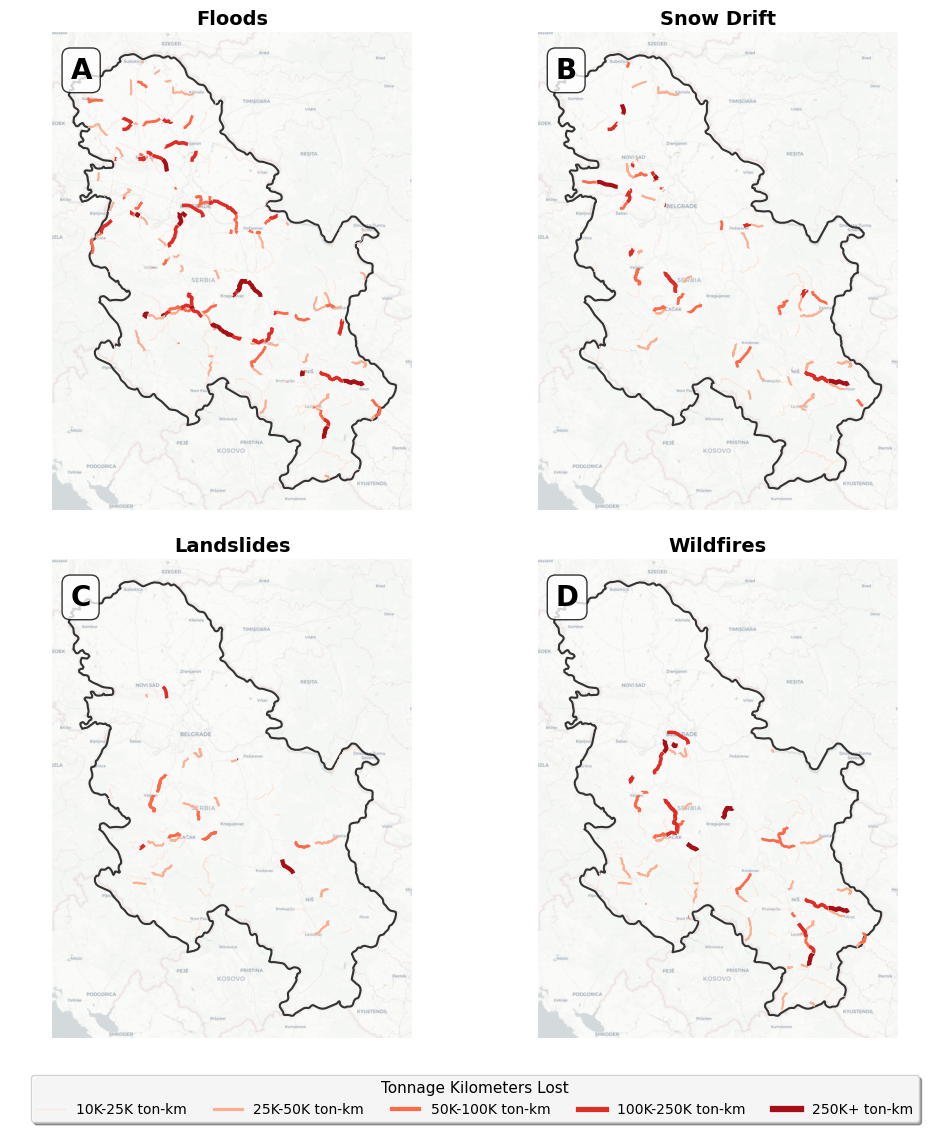

In [18]:
# 2x2 hazard comparison figures for VHL, PHL and TKL
plot_all_hazard_comparisons(
    gdf_vhl_flooded, gdf_vhl_snowdrift, gdf_vhl_landslides,
    gdf_vhl_wildfire, country_plot, figure_path,
)

In [19]:
print_hazard_analysis_summary(
    gdf_results, gdf_vhl_flooded, gdf_vhl_snowdrift,
    gdf_vhl_landslides, gdf_vhl_wildfire,
)

BASELINE RESULTS - ALL METRICS

Total road segments analyzed: 3,250

All Metrics Summary:
              phl        thl         pkl         tkl
count     2403.00    2403.00     2403.00     2403.00
mean      3045.01    1365.28   108881.43    76470.57
std      31424.80    4576.07   241984.63   215123.70
min          0.00       0.00        0.00        0.00
25%        123.35      44.56    10686.40     3810.10
50%        386.17     152.33    32604.79    12445.94
75%       1442.00     709.14    95340.97    47765.65
max    1462059.68  101107.21  3693338.82  3694177.48

Totals across network:
  Total PHL: 7,317,163 passenger hours
  Total THL: 3,280,763 ton hours
  Total PKL: 261,642,066 passenger km
  Total TKL: 183,758,789 ton km

PASSENGER HOURS LOST (PHL) BY HAZARD

──────────────────────────────────────────────────
FLOODS
──────────────────────────────────────────────────
Exposed road segments: 859
count       796.00
mean       1595.13
std        6999.30
min           0.00
25%         113.

## Multi-Hazard Exposure Count

Binary yes/no exposure across six hazards (flood, snow drift, landslide, wildfire, pavement heat > 60°C, projected extreme-rainfall change ≥ 10%), mapped by how many hazards affect each road segment.


In [ ]:
# Binary exposure flag per hazard, then a per-segment hazard count
hazard_specs = [
    ("hazard_flood", "Flood", gdf_results.index.isin(gdf_vhl_flooded.index)),
    ("hazard_snow_drift", "Snow drift", gdf_results.index.isin(gdf_vhl_snowdrift.index)),
    ("hazard_landslide", "Landslide", gdf_results.index.isin(gdf_vhl_landslides.index)),
    ("hazard_wildfire", "Wildfire", gdf_results.index.isin(gdf_vhl_wildfire.index)),
    ("hazard_heat", "Heat (pavement > 60°C)",
     (gdf_vhl_heat["max_pavement_temp"] > 60).reindex(gdf_results.index, fill_value=False).to_numpy()),
    ("hazard_future_precipitation", "Future precipitation (≥ 10% change)",
     flag_future_precipitation(
         gdf_results,
         parquet_dir / "change in maximum daily precipitation rcp 85 period 2.parquet",
         threshold=10.0,
     )),
]

gdf_hazard_count = build_hazard_count(gdf_results, hazard_specs)
plot_hazard_count_map(gdf_hazard_count, figure_path, n_hazards=len(hazard_specs))
summarize_hazard_counts(gdf_hazard_count, hazard_specs)
